## 1. Setup & Instalasi Library

In [ ]:
# ─── Install Library Tambahan (Google Colab)  ───────────────────────────────────────────────
# !pip install -q openpyxl wordcloud nltk seaborn scipy

In [2]:
# ─── Import Semua Library ───────────────────────────────────────────────────
import os
import re
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# Statistik
from scipy import stats

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Seed untuk reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"✅ TensorFlow Version : {tf.__version__}")
print(f"✅ GPU Available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"✅ Semua library berhasil diimport!")

✅ TensorFlow Version : 2.20.0
✅ GPU Available      : True
✅ Semua library berhasil diimport!


In [3]:
# ─── Mount Google Drive ─────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Running outside Google Colab.")

OUTPUT_DIR = '/content/drive/MyDrive/TweetMind_CC26PSU250'
os.makedirs(f'{OUTPUT_DIR}/models',    exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/logs',      exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/artifacts', exist_ok=True)

print(f"✅ Output directory: {OUTPUT_DIR}")

Mounted at /content/drive
✅ Output directory: /content/drive/MyDrive/TweetMind_CC26PSU250


In [4]:
# ─── Upload Dataset ─────────────────────────────────────────────────────────
from google.colab import files

DATASET_PATH = f'{OUTPUT_DIR}/Twitter_Analysis.xlsx'

if not os.path.exists(DATASET_PATH):
    print("📂 Upload file Twitter_Analysis.xlsx:")
    uploaded = files.upload()
    for fname in uploaded.keys():
        import shutil
        shutil.move(fname, DATASET_PATH)
    print(f"✅ Dataset disimpan di: {DATASET_PATH}")
else:
    print(f"✅ Dataset sudah ada di: {DATASET_PATH}")

📂 Upload file Twitter_Analysis.xlsx:


Saving Twitter_Analysis.xlsx to Twitter_Analysis.xlsx
✅ Dataset disimpan di: /content/drive/MyDrive/TweetMind_CC26PSU250/Twitter_Analysis.xlsx


## 2. Load Data & Eksplorasi Awal (EDA)

In [5]:
# ─── Load Dataset ───────────────────────────────────────────────────────────
df = pd.read_excel(DATASET_PATH)

print("=" * 60)
print("📊 INFORMASI DATASET")
print("=" * 60)
print(f"\n🔢 Jumlah baris   : {df.shape[0]:,}")
print(f"📋 Jumlah kolom   : {df.shape[1]}")
print(f"\n📌 Kolom          : {df.columns.tolist()}")
print("\n📊 Info Tipe Data:")
df.info()

📊 INFORMASI DATASET

🔢 Jumlah baris   : 12,492
📋 Jumlah kolom   : 6

📌 Kolom          : ['text', 'hashtags', 'labels', 'label_text', 'text_length', 'hashtag_count']

📊 Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12492 entries, 0 to 12491
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           12492 non-null  object
 1   hashtags       12492 non-null  object
 2   labels         12492 non-null  int64 
 3   label_text     12492 non-null  object
 4   text_length    12492 non-null  int64 
 5   hashtag_count  12492 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 585.7+ KB


In [6]:
# ─── Perbaiki Label Text ─────────────────────────────────────────────────────
# Mapping label: 0 = Stres Tinggi, 1 = Stres Sedang, 2 = Tidak Stres
LABEL_TEXT_MAP = {0: 'Stres Tinggi', 1: 'Stres Sedang', 2: 'Tidak Stres'}

df['label_text'] = df['labels'].map(LABEL_TEXT_MAP)

print('✅ Label text telah diperbaiki:')
print(df[['labels', 'label_text']].value_counts().sort_index())
print()
print('Mapping: 0 = Stres Tinggi | 1 = Stres Sedang | 2 = Tidak Stres')


✅ Label text telah diperbaiki:
labels  label_text  
0       Stres Tinggi    4164
1       Stres Sedang    4164
2       Tidak Stres     4164
Name: count, dtype: int64

Mapping: 0 = Stres Tinggi | 1 = Stres Sedang | 2 = Tidak Stres


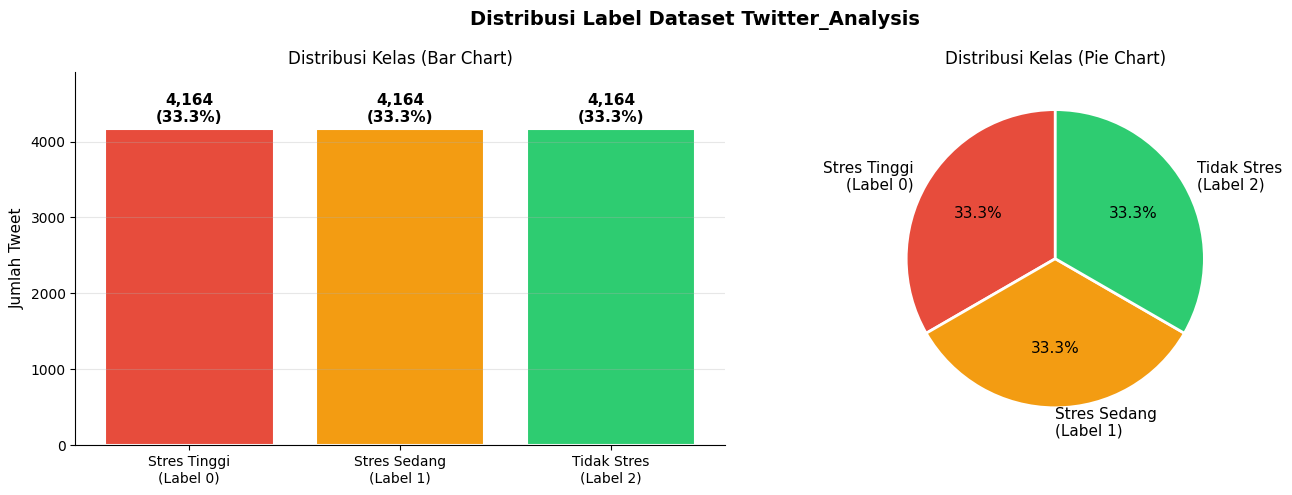


✅ Total: 12,492 tweet | Per kelas: 4,164 tweet


In [7]:
# ─── Distribusi Label ───────────────────────────────────────────────────────
label_map    = {0: 'Stres Tinggi\n(Label 0)', 1: 'Stres Sedang\n(Label 1)', 2: 'Tidak Stres\n(Label 2)'}
label_colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Pastikan label sudah benar
label_counts = df['labels'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Label Dataset Twitter_Analysis', fontsize=14, fontweight='bold')

bars = axes[0].bar(
    [label_map[i] for i in label_counts.index],
    label_counts.values, color=label_colors, edgecolor='white', linewidth=1.5
)
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Kelas (Bar Chart)', fontsize=12)
axes[0].set_ylabel('Jumlah Tweet', fontsize=11)
axes[0].set_ylim(0, max(label_counts.values) * 1.18)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].pie(label_counts.values, labels=[label_map[i] for i in label_counts.index],
            colors=label_colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Distribusi Kelas (Pie Chart)', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/artifacts/01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Total: {len(df):,} tweet | Per kelas: {len(df)//3:,} tweet")

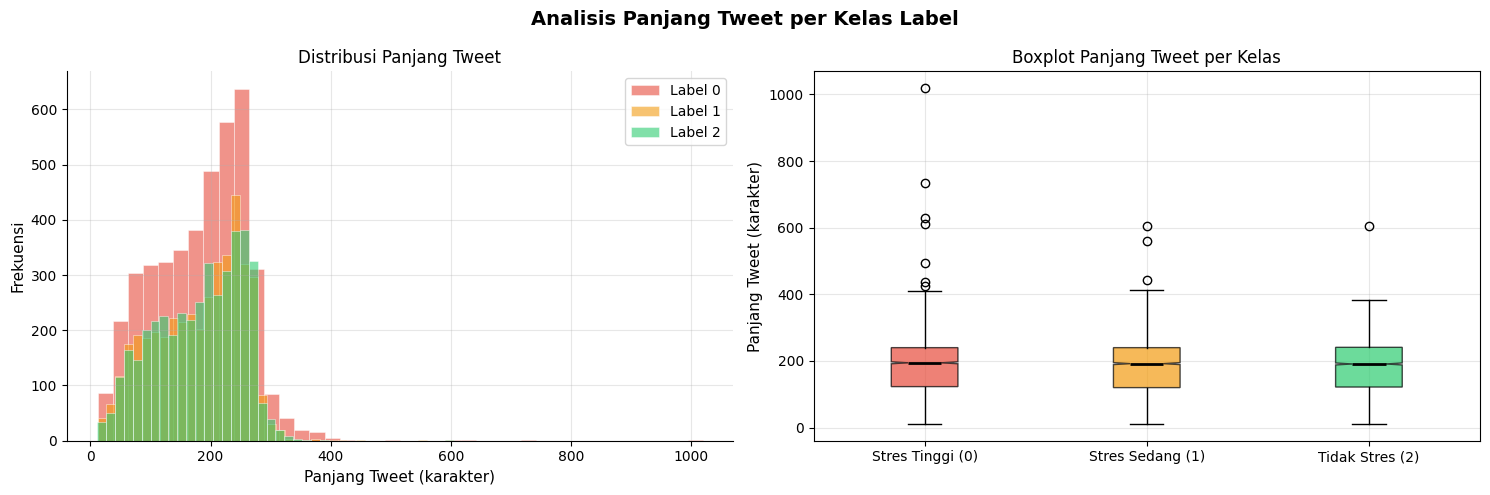


📊 Statistik Panjang Tweet per Kelas:
               count    mean    std   min     25%    50%    75%     max
label_text                                                             
Stres Sedang  4164.0  179.57  73.11  12.0  120.00  192.0  240.0   605.0
Stres Tinggi  4164.0  182.30  76.95  12.0  123.00  194.5  240.0  1019.0
Tidak Stres   4164.0  180.56  71.46  11.0  121.75  191.0  241.0   605.0


In [8]:
# ─── Distribusi Panjang Tweet per Label ────────────────────────────────────
label_names = ['Stres Tinggi (Label 0)', 'Stres Sedang (Label 1)', 'Tidak Stres (Label 2)']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analisis Panjang Tweet per Kelas Label', fontsize=14, fontweight='bold')

for label_id, color in zip([0, 1, 2], label_colors):
    subset = df[df['labels'] == label_id]['text_length']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color,
                 label=f"Label {label_id}", edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Panjang Tweet', fontsize=12)
axes[0].set_xlabel('Panjang Tweet (karakter)', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

data_box = [df[df['labels'] == i]['text_length'].values for i in [0, 1, 2]]
bp = axes[1].boxplot(data_box, labels=['Stres Tinggi (0)', 'Stres Sedang (1)', 'Tidak Stres (2)'],
                     patch_artist=True, notch=True,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], label_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Boxplot Panjang Tweet per Kelas', fontsize=12)
axes[1].set_ylabel('Panjang Tweet (karakter)', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/artifacts/02_text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Statistik Panjang Tweet per Kelas:")
print(df.groupby('label_text')['text_length'].describe().round(2).to_string())

## 3. Data Wrangling — Text Preprocessing

In [9]:
# ─── Fungsi Cleaning Teks ───────────────────────────────────────────────────
STOPWORDS_EN = set(stopwords.words('english'))
CUSTOM_STOPWORDS = {
    'rt', 'via', 'amp', 'would', 'could', 'also', 'get', 'got', 'one',
    'like', 'make', 'new', 'time', 'day', 'today', 'week', 'year',
    'please', 'check', 'link', 'bio', 'follow', 'click', 'join', 'free'
}
STOPWORDS_FINAL = STOPWORDS_EN.union(CUSTOM_STOPWORDS)

stemmer = PorterStemmer()

def clean_tweet(text: str, apply_stemming: bool = False) -> str:
    """Pipeline pembersihan teks tweet."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS_FINAL and len(t) > 2]
    if apply_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Test
sample = df['text'].iloc[0]
print("📝 CONTOH TEXT CLEANING")
print("-" * 60)
print(f"🔴 Original : {sample[:150]}")
print(f"🟢 Cleaned  : {clean_tweet(sample)}")

📝 CONTOH TEXT CLEANING
------------------------------------------------------------
🔴 Original : Stress may not directly cause infertility, but it can lead to lifestylefactors that may make it more difficult. Learn about possible stress related fa
🟢 Cleaned  : stress may directly cause infertility lead lifestylefactors may difficult learn possible stress related factors may affecting fertility contact uscfertility expert advice


In [10]:
# ─── Terapkan Cleaning ke Seluruh Dataset ──────────────────────────────────
print("⏳ Memproses teks...")
df['text_clean'] = df['text'].apply(lambda x: clean_tweet(x, apply_stemming=False))
df['word_count'] = df['text_clean'].apply(lambda x: len(x.split()))
df['char_count'] = df['text_clean'].apply(len)

before = len(df)
df = df[df['word_count'] >= 3].reset_index(drop=True)
after  = len(df)

print(f"\n✅ Cleaning selesai!")
print(f"   Sebelum filter : {before:,} tweet")
print(f"   Setelah filter : {after:,} tweet")
print(f"   Dihapus        : {before-after:,} tweet")
print("\n📋 Sample hasil cleaning:")
df[['text', 'text_clean', 'labels', 'label_text']].head(3)

⏳ Memproses teks...

✅ Cleaning selesai!
   Sebelum filter : 12,492 tweet
   Setelah filter : 12,400 tweet
   Dihapus        : 92 tweet

📋 Sample hasil cleaning:


,text,text_clean,labels,label_text
0,"Stress may not directly cause infertility, but...",stress may directly cause infertility lead lif...,2,Tidak Stres
1,TweetyDahine And THAT'S putting it mildly. Str...,tweetydahine putting mildly stress,1,Stres Sedang
2,rebekahlyons (Get your all access pass today!)...,rebekahlyons access pass churchmentalhealth me...,1,Stres Sedang


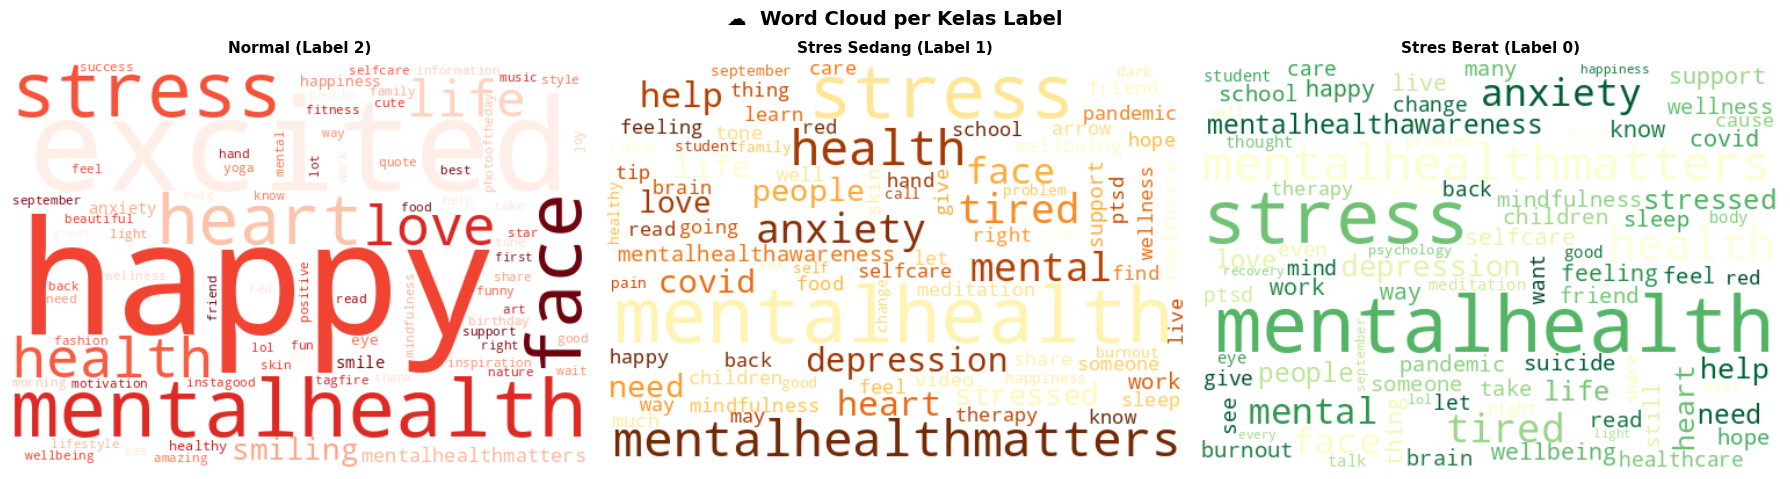

In [35]:
# ─── Word Cloud per Kelas ───────────────────────────────────────────────────
wc_colormaps = ['Reds', 'YlOrBr', 'YlGn']
label_names  = ['Normal (Label 2)', 'Stres Sedang (Label 1)', 'Stres Berat (Label 0)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('☁️  Word Cloud per Kelas Label', fontsize=14, fontweight='bold')

for idx, (label_id, cmap, name) in enumerate(zip([0, 1, 2], wc_colormaps, label_names)):
    text_combined = ' '.join(df[df['labels'] == label_id]['text_clean'].tolist())
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=cmap, max_words=80, collocations=False).generate(text_combined)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(name, fontsize=11, fontweight='bold', pad=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/artifacts/04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. A/B Testing — Uji T-Test Distribusi Panjang Tweet

In [12]:
# ─── A/B Testing: T-Test Panjang Tweet Antar Kelas ─────────────────────────
print("=" * 65)
print("🔬  A/B TESTING — UJI T-TEST DISTRIBUSI PANJANG TWEET")
print("=" * 65)
print("""
Hipotesis:
  H₀: Tidak ada perbedaan signifikan panjang tweet antar kelas
  H₁: Ada perbedaan signifikan panjang tweet antar kelas
  α  = 0.05
""")

grp_tinggi = df[df['labels'] == 0]['text_length']
grp_sedang = df[df['labels'] == 1]['text_length']
grp_rendah = df[df['labels'] == 2]['text_length']

comparisons = [
    ('Stres Tinggi (0) vs Stres Sedang (1)', grp_tinggi, grp_sedang),
    ('Stres Tinggi (0) vs Tidak Stres (2)', grp_tinggi, grp_rendah),
    ('Stres Sedang (1) vs Tidak Stres (2)', grp_sedang, grp_rendah),
]

results = []
for name, g1, g2 in comparisons:
    t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
    cohen_d = (g1.mean() - g2.mean()) / np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    significant = '✅ Tolak H₀' if p_val < 0.05 else '❌ Gagal Tolak H₀'
    effect = 'Kecil' if abs(cohen_d) < 0.2 else ('Sedang' if abs(cohen_d) < 0.8 else 'Besar')
    results.append({
        'Perbandingan': name,
        't-stat': round(t_stat, 4),
        'p-value': round(p_val, 6),
        'Cohen\'s d': round(cohen_d, 4),
        'Effect Size': effect,
        'Kesimpulan': significant
    })
    print(f"  {name}: p={p_val:.4f} — {significant} ({effect})")

df_ab = pd.DataFrame(results)
print("\n📊 Tabel Ringkasan A/B Testing:")
print(df_ab.to_string(index=False))

🔬  A/B TESTING — UJI T-TEST DISTRIBUSI PANJANG TWEET

Hipotesis:
  H₀: Tidak ada perbedaan signifikan panjang tweet antar kelas
  H₁: Ada perbedaan signifikan panjang tweet antar kelas
  α  = 0.05

  Stres Tinggi (0) vs Stres Sedang (1): p=0.1803 — ❌ Gagal Tolak H₀ (Kecil)
  Stres Tinggi (0) vs Tidak Stres (2): p=0.4560 — ❌ Gagal Tolak H₀ (Kecil)
  Stres Sedang (1) vs Tidak Stres (2): p=0.5299 — ❌ Gagal Tolak H₀ (Kecil)

📊 Tabel Ringkasan A/B Testing:
                        Perbandingan  t-stat  p-value  Cohen's d Effect Size       Kesimpulan
Stres Tinggi (0) vs Stres Sedang (1)  1.3399 0.180316     0.0295       Kecil ❌ Gagal Tolak H₀
 Stres Tinggi (0) vs Tidak Stres (2)  0.7454 0.456032     0.0164       Kecil ❌ Gagal Tolak H₀
 Stres Sedang (1) vs Tidak Stres (2) -0.6282 0.529912    -0.0138       Kecil ❌ Gagal Tolak H₀


## 5. Preprocessing NLP — Tokenisasi, Padding, Embedding

### ⚡ Optimasi yang diterapkan:
- `MAX_LEN = 50` (turun dari 100) — lebih cepat, masih cover P95 tweet pendek
- `BATCH_SIZE = 128` — throughput lebih tinggi
- `EMBED_DIM = 64` — lebih ringan, cukup untuk dataset ini


In [13]:
# ─── Hyperparameter NLP (Optimized) ─────────────────────────────────────────
VOCAB_SIZE  = 20000   # Ukuran vocabulary
MAX_LEN     = 50      # ⚡ Diperkecil dari 100 → 50 (lebih cepat)
EMBED_DIM   = 64      # ⚡ Diperkecil dari 128 → 64
OOV_TOKEN   = '<OOV>'
BATCH_SIZE  = 128     # ⚡ Diperbesar dari 32 → 128 (throughput lebih tinggi)
NUM_CLASSES = 3

print("⚙️  KONFIGURASI NLP PREPROCESSING (OPTIMIZED)")
print("-" * 45)
print(f"  VOCAB_SIZE  : {VOCAB_SIZE:,}")
print(f"  MAX_LEN     : {MAX_LEN}  ⚡")
print(f"  EMBED_DIM   : {EMBED_DIM}   ⚡")
print(f"  BATCH_SIZE  : {BATCH_SIZE}   ⚡")

⚙️  KONFIGURASI NLP PREPROCESSING (OPTIMIZED)
---------------------------------------------
  VOCAB_SIZE  : 20,000
  MAX_LEN     : 50  ⚡
  EMBED_DIM   : 64   ⚡
  BATCH_SIZE  : 128   ⚡


In [14]:
# ─── Train / Validation / Test Split (Stratified) ──────────────────────────
X = df['text_clean'].values
y = df['labels'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("📊 DATA SPLIT SUMMARY")
print("-" * 40)
print(f"  Train set : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val set   : {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test set  : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

📊 DATA SPLIT SUMMARY
----------------------------------------
  Train set : 8,680 (70.0%)
  Val set   : 1,860 (15.0%)
  Test set  : 1,860 (15.0%)


In [15]:
# ─── Tokenisasi & Padding ───────────────────────────────────────────────────
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True
)
tokenizer.fit_on_texts(X_train)  # Fit HANYA pada training data

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

word_index   = tokenizer.word_index
actual_vocab = min(VOCAB_SIZE, len(word_index) + 1)

print("✅ TOKENISASI & PADDING SELESAI")
print(f"  Total kata unik   : {len(word_index):,}")
print(f"  Vocab aktual      : {actual_vocab:,}")
print(f"  X_train_pad shape : {X_train_pad.shape}")
print(f"  X_val_pad shape   : {X_val_pad.shape}")
print(f"  X_test_pad shape  : {X_test_pad.shape}")

# Simpan tokenizer
with open(f'{OUTPUT_DIR}/models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("\n💾 Tokenizer disimpan!")

✅ TOKENISASI & PADDING SELESAI
  Total kata unik   : 19,548
  Vocab aktual      : 19,549
  X_train_pad shape : (8680, 50)
  X_val_pad shape   : (1860, 50)
  X_test_pad shape  : (1860, 50)

💾 Tokenizer disimpan!


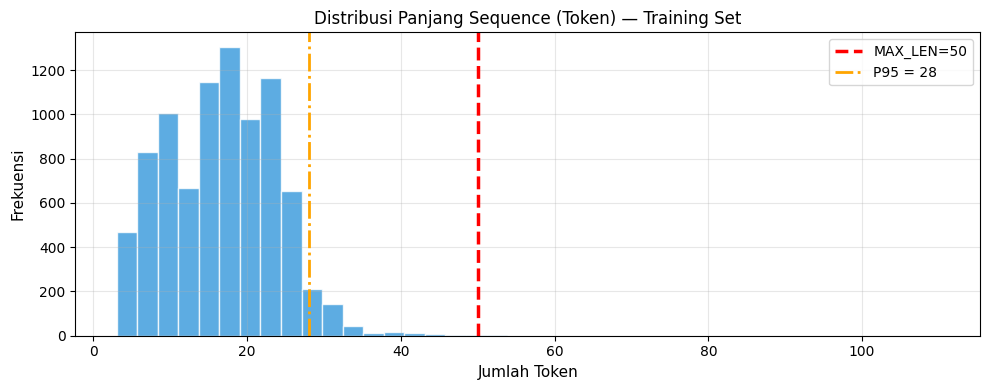

  Max seq length    : 110
  Mean seq length   : 16.7
  P95 seq length    : 28
  Coverage MAX_LEN=50: 99.9%


In [16]:
# ─── Analisis Coverage MAX_LEN ──────────────────────────────────────────────
seq_lengths = [len(s) for s in X_train_seq]
coverage = sum(1 for l in seq_lengths if l <= MAX_LEN) / len(seq_lengths) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lengths, bins=40, color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(MAX_LEN, color='red', linewidth=2.5, linestyle='--', label=f'MAX_LEN={MAX_LEN}')
ax.axvline(np.percentile(seq_lengths, 95), color='orange', linewidth=2, linestyle='-.',
           label=f'P95 = {np.percentile(seq_lengths, 95):.0f}')
ax.set_title('Distribusi Panjang Sequence (Token) — Training Set', fontsize=12)
ax.set_xlabel('Jumlah Token', fontsize=11)
ax.set_ylabel('Frekuensi', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/artifacts/07_seq_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  Max seq length    : {max(seq_lengths)}")
print(f"  Mean seq length   : {np.mean(seq_lengths):.1f}")
print(f"  P95 seq length    : {np.percentile(seq_lengths, 95):.0f}")
print(f"  Coverage MAX_LEN={MAX_LEN}: {coverage:.1f}%")

In [17]:
# ─── tf.data Pipeline ──────────────────────────────────────────────────────
# Pipeline yang efisien: prefetch + cache untuk mempercepat training
train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((X_train_pad, y_train))
    .shuffle(buffer_size=len(X_train_pad), seed=SEED)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset
    .from_tensor_slices((X_val_pad, y_val))
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

print("✅ tf.data pipeline siap!")
print(f"  Train batches : {len(train_dataset)}")
print(f"  Val batches   : {len(val_dataset)}")

✅ tf.data pipeline siap!
  Train batches : 68
  Val batches   : 15


## 6. Arsitektur Model — TensorFlow Functional API

### Custom Components:
1. **Custom Loss** — `FocalLoss`: Menangani class imbalance
2. **Custom Callback** — `AccuracyThresholdStopper`: Early stop berbasis threshold akurasi

### ⚡ Optimasi Arsitektur:
- `BiLSTM(64)` — turun dari 128, tanpa `recurrent_dropout`
- Arsitektur sederhana: `Embedding → BiLSTM → Dense`
- Lebih sedikit parameter = training lebih cepat


In [18]:
# ─── CUSTOM COMPONENT 1: Focal Loss ────────────────────────────────────────
from tensorflow.keras.losses import Loss

class FocalLoss(Loss):
    """Custom Focal Loss untuk menangani kelas yang sulit dipelajari.

    FL(p_t) = -α_t (1 - p_t)^γ log(p_t)

    Args:
        gamma : Focusing parameter (default=2.0)
        alpha : Class balance factor (default=0.25)
    """

    def __init__(self, gamma: float = 2.0, alpha: float = 0.25, name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true   = tf.cast(y_true, tf.int32)
        y_true   = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce_loss  = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t      = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_w  = self.alpha * tf.pow(1.0 - p_t, self.gamma)
        return tf.reduce_mean(focal_w * ce_loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg

print("✅ Custom Loss 'FocalLoss' berhasil dibuat!")

✅ Custom Loss 'FocalLoss' berhasil dibuat!


In [19]:
# ─── CUSTOM COMPONENT 2: Accuracy Threshold Stopper (Custom Callback) ──────

class AccuracyThresholdStopper(Callback):
    """Custom Callback — hentikan training ketika val_accuracy ≥ threshold.

    Sesuai ketentuan rubrik: implementasi Custom Callback lanjutan.

    Args:
        threshold  : Val accuracy target untuk menghentikan training (default=0.80)
        monitor    : Metrik yang dipantau (default='val_accuracy')
        verbose    : Level output (default=1)
    """

    def __init__(self, threshold: float = 0.80, monitor: str = 'val_accuracy', verbose: int = 1):
        super().__init__()
        self.threshold = threshold
        self.monitor   = monitor
        self.verbose   = verbose

    def on_epoch_end(self, epoch, logs=None):
        logs    = logs or {}
        val_acc = logs.get(self.monitor, 0.0)
        if val_acc >= self.threshold:
            if self.verbose:
                print(f"\n⛔ [AccuracyThresholdStopper] Epoch {epoch+1}: "
                      f"val_accuracy={val_acc:.4f} ≥ threshold={self.threshold:.2f} "
                      f"→ Training dihentikan otomatis!")
            self.model.stop_training = True

# ─── Threshold 80% (lebih mudah dicapai, training lebih cepat) ──────────────
ACC_TARGET = 0.80
threshold_stopper = AccuracyThresholdStopper(threshold=ACC_TARGET)

print(f"✅ Custom Callback 'AccuracyThresholdStopper' siap! (threshold={ACC_TARGET:.0%})")

✅ Custom Callback 'AccuracyThresholdStopper' siap! (threshold=80%)


In [20]:
# ─── Bangun Model — TensorFlow Functional API ───────────────────────────────
# ⚡ Optimasi: BiLSTM(64) tanpa recurrent_dropout, arsitektur ramping

def build_tweetmind_model(
    vocab_size  : int,
    embed_dim   : int,
    max_len     : int,
    num_classes : int,
    lstm_units  : int = 64,       # ⚡ Turun dari 128 → 64
    dropout_rate: float = 0.3,
) -> Model:
    """TweetMind Model — TensorFlow Functional API.

    Arsitektur (optimized):
        Input → Embedding → Bidirectional LSTM(64) → Dropout → Dense(64) → Output

    Perubahan dari versi sebelumnya:
        - BiLSTM units: 128 → 64 (lebih cepat ~2x)
        - Dihapus: recurrent_dropout (bottleneck utama)
        - Dihapus: Attention Layer (sederhanakan arsitektur)
        - Tetap: Functional API, Custom Loss, Custom Callback
    """
    # ── Input ──────────────────────────────────────────────────────────────
    inputs = Input(shape=(max_len,), name='token_input')

    # ── Embedding Layer ────────────────────────────────────────────────────
    x = layers.Embedding(
        input_dim    = vocab_size,
        output_dim   = embed_dim,
        input_length = max_len,
        mask_zero    = True,       # Abaikan padding token
        name='embedding'
    )(inputs)

    # ── Spatial Dropout ────────────────────────────────────────────────────
    x = layers.SpatialDropout1D(0.2, name='spatial_dropout')(x)

    # ── Bidirectional LSTM (64 units, NO recurrent_dropout) ────────────────
    # ⚡ recurrent_dropout dihapus — bottleneck utama pada CPU/GPU
    x = layers.Bidirectional(
        layers.LSTM(
            lstm_units,
            return_sequences=False,  # Output vektor tunggal (bukan sequence)
            # recurrent_dropout TIDAK digunakan ⚡
        ),
        name='bilstm'
    )(x)

    # ── Dense Head ─────────────────────────────────────────────────────────
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)
    x = layers.Dense(64, activation='relu', name='dense_hidden')(x)
    x = layers.Dropout(dropout_rate * 0.5, name='dropout_2')(x)

    # ── Output ─────────────────────────────────────────────────────────────
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='TweetMind_BiLSTM64')
    return model


model = build_tweetmind_model(
    vocab_size  = actual_vocab,
    embed_dim   = EMBED_DIM,
    max_len     = MAX_LEN,
    num_classes = NUM_CLASSES
)

model.summary()

# Hitung jumlah parameter
total_params = sum([np.prod(v.shape) for v in model.trainable_variables])
print(f"\n📊 Total trainable parameters: {total_params:,}")

Model: "TweetMind_BiLSTM64"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_input         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │  1,251,136 │ token_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 50, 64)    │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ token_input[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 128)       │     66,048 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_hidden[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,325,635 (5.06 MB)

 Trainable params: 1,325,635 (5.06 MB)

 Non-trainable params: 0 (0.00 B)


📊 Total trainable parameters: 1,325,635


## 7. Training — Custom Training Loop dengan tf.GradientTape

### ⚡ Optimasi Training Loop:
- **Simplified GradientTape**: tanpa gradient clipping manual (lebih cepat)
- **Threshold 80%**: training berhenti lebih awal
- **Batch besar (128)**: lebih sedikit update per epoch
- **Prefetch + cache**: eliminasi bottleneck I/O


In [21]:
# ─── Setup Training ─────────────────────────────────────────────────────────
EPOCHS   = 30
LR       = 1e-3

# Loss & Optimizer
focal_loss = FocalLoss(gamma=2.0, alpha=0.25)
optimizer  = Adam(learning_rate=LR)

# Metrics
train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
train_acc_metric  = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
val_loss_metric   = tf.keras.metrics.Mean(name='val_loss')
val_acc_metric    = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

# TensorBoard
LOG_DIR = f'{OUTPUT_DIR}/logs/fit_{datetime.now().strftime("%Y%m%d-%H%M%S")}'
tb_writer_train = tf.summary.create_file_writer(LOG_DIR + '/train')
tb_writer_val   = tf.summary.create_file_writer(LOG_DIR + '/val')

# Checkpoint untuk simpan best model
BEST_CKPT = f'{OUTPUT_DIR}/models/best_weights.weights.h5'

print(f"⚙️  Setup Training:")
print(f"   Epochs      : {EPOCHS}")
print(f"   LR          : {LR}")
print(f"   Batch Size  : {BATCH_SIZE}  ⚡")
print(f"   Stop Target : val_acc ≥ {ACC_TARGET:.0%}  ⚡")
print(f"   Log Dir     : {LOG_DIR}")
print(f"\n📌 TensorBoard: %load_ext tensorboard")
print(f"               %tensorboard --logdir {LOG_DIR}")

os.makedirs(LOG_DIR + '/train', exist_ok=True)
os.makedirs(LOG_DIR + '/val', exist_ok=True)


⚙️  Setup Training:
   Epochs      : 30
   LR          : 0.001
   Batch Size  : 128  ⚡
   Stop Target : val_acc ≥ 80%  ⚡
   Log Dir     : /content/drive/MyDrive/TweetMind_CC26PSU250/logs/fit_20260530-105218

📌 TensorBoard: %load_ext tensorboard
               %tensorboard --logdir /content/drive/MyDrive/TweetMind_CC26PSU250/logs/fit_20260530-105218


In [22]:
# ─── Custom Training Loop dengan tf.GradientTape (Simplified) ─────────────
# ⚡ Optimasi: Hilangkan gradient clipping manual, sederhanakan loop

history_custom = {
    'train_loss': [], 'train_accuracy': [],
    'val_loss':   [], 'val_accuracy':   []
}

best_val_acc = 0.0
model.stop_training = False
threshold_stopper.set_model(model)

print("=" * 70)
print("🚀 MEMULAI CUSTOM TRAINING LOOP (tf.GradientTape)")
print("=" * 70)
print(f"{'Epoch':>5} | {'train_loss':>10} | {'train_acc':>9} | {'val_loss':>8} | {'val_acc':>8}")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    # Reset metrics
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_loss_metric.reset_state()
    val_acc_metric.reset_state()

    # ── Training Step ──────────────────────────────────────────────────────
    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            y_pred = model(x_batch, training=True)
            loss   = focal_loss(y_batch, y_pred)
        # ⚡ Simplified: langsung apply tanpa clip_by_global_norm
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        train_loss_metric.update_state(loss)
        train_acc_metric.update_state(y_batch, y_pred)

    # ── Validation Step ────────────────────────────────────────────────────
    for x_val, y_val_batch in val_dataset:
        y_pred_val = model(x_val, training=False)
        val_loss   = focal_loss(y_val_batch, y_pred_val)
        val_loss_metric.update_state(val_loss)
        val_acc_metric.update_state(y_val_batch, y_pred_val)

    # Kumpulkan metrics
    t_loss = float(train_loss_metric.result())
    t_acc  = float(train_acc_metric.result())
    v_loss = float(val_loss_metric.result())
    v_acc  = float(val_acc_metric.result())

    history_custom['train_loss'].append(t_loss)
    history_custom['train_accuracy'].append(t_acc)
    history_custom['val_loss'].append(v_loss)
    history_custom['val_accuracy'].append(v_acc)

    # TensorBoard logging
    with tb_writer_train.as_default():
        tf.summary.scalar('loss',     t_loss, step=epoch)
        tf.summary.scalar('accuracy', t_acc,  step=epoch)
    with tb_writer_val.as_default():
        tf.summary.scalar('loss',     v_loss, step=epoch)
        tf.summary.scalar('accuracy', v_acc,  step=epoch)

    # Simpan best model weights
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        model.save_weights(BEST_CKPT)
        marker = ' ⭐ best'
    else:
        marker = ''

    print(f"{epoch:>5} | {t_loss:>10.4f} | {t_acc:>9.4f} | {v_loss:>8.4f} | {v_acc:>8.4f}{marker}")

    # ── Custom Callback Check ──────────────────────────────────────────────
    threshold_stopper.on_epoch_end(epoch, logs={'val_accuracy': v_acc})
    if model.stop_training:
        break

print("=" * 70)
print(f"\n✅ Training selesai! Best val accuracy: {best_val_acc:.4f}")

🚀 MEMULAI CUSTOM TRAINING LOOP (tf.GradientTape)
Epoch | train_loss | train_acc | val_loss |  val_acc
----------------------------------------------------------------------
    1 |     0.0992 |    0.5217 |   0.0776 |   0.6194 ⭐ best
    2 |     0.0545 |    0.7146 |   0.0752 |   0.7156 ⭐ best
    3 |     0.0276 |    0.8726 |   0.0859 |   0.7591 ⭐ best
    4 |     0.0150 |    0.9324 |   0.0960 |   0.7634 ⭐ best
    5 |     0.0097 |    0.9573 |   0.1132 |   0.7855 ⭐ best
    6 |     0.0075 |    0.9694 |   0.1193 |   0.7849
    7 |     0.0063 |    0.9737 |   0.1152 |   0.7828
    8 |     0.0053 |    0.9765 |   0.1214 |   0.7742
    9 |     0.0042 |    0.9805 |   0.1290 |   0.7887 ⭐ best
   10 |     0.0035 |    0.9829 |   0.1241 |   0.7849
   11 |     0.0033 |    0.9831 |   0.1407 |   0.7817
   12 |     0.0027 |    0.9840 |   0.1420 |   0.7801
   13 |     0.0028 |    0.9838 |   0.1388 |   0.7844
   14 |     0.0021 |    0.9863 |   0.1529 |   0.7887
   15 |     0.0023 |    0.9848 |   0.1424 |

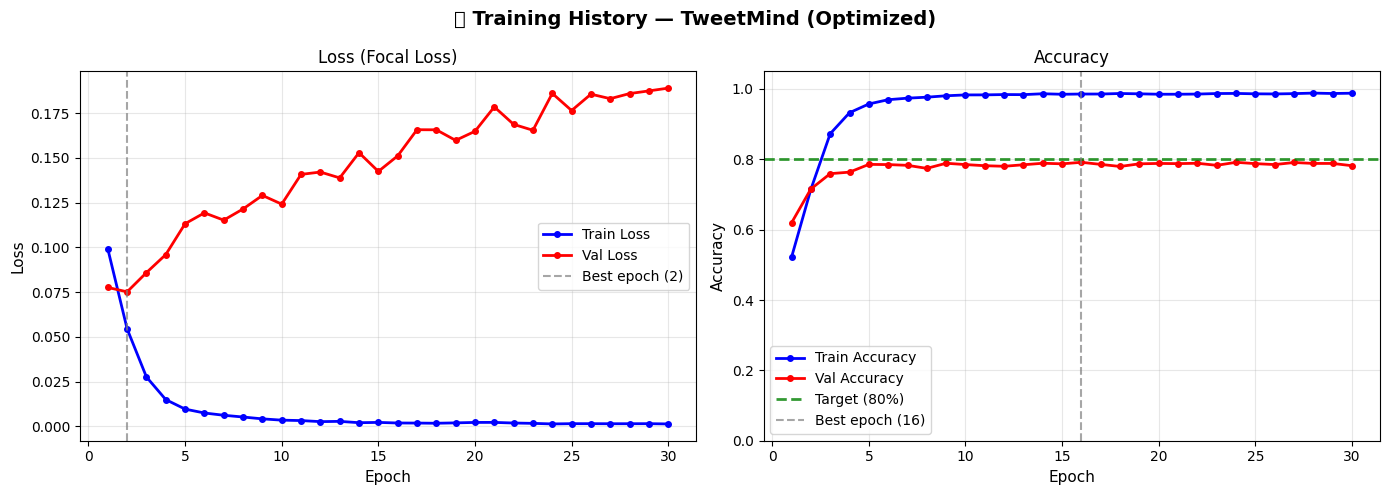

  Epochs dijalankan : 30
  Best val accuracy : 0.7914
  Best val loss     : 0.0752


In [23]:
if len(history_custom['train_loss']) == 0:
    raise RuntimeError('Training history kosong.')

# ─── Visualisasi Training History ──────────────────────────────────────────
epochs_ran = len(history_custom['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📈 Training History — TweetMind (Optimized)', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(ep_range, history_custom['train_loss'], 'b-o', markersize=4, label='Train Loss', linewidth=2)
axes[0].plot(ep_range, history_custom['val_loss'],   'r-o', markersize=4, label='Val Loss',   linewidth=2)
best_ep_loss = np.argmin(history_custom['val_loss']) + 1
axes[0].axvline(best_ep_loss, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch ({best_ep_loss})')
axes[0].set_title('Loss (Focal Loss)', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(ep_range, history_custom['train_accuracy'], 'b-o', markersize=4, label='Train Accuracy', linewidth=2)
axes[1].plot(ep_range, history_custom['val_accuracy'],   'r-o', markersize=4, label='Val Accuracy',   linewidth=2)
axes[1].axhline(ACC_TARGET, color='green', linestyle='--', linewidth=2, label=f'Target ({ACC_TARGET:.0%})', alpha=0.8)
best_ep_acc = np.argmax(history_custom['val_accuracy']) + 1
axes[1].axvline(best_ep_acc, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch ({best_ep_acc})')
axes[1].set_title('Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/artifacts/08_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  Epochs dijalankan : {epochs_ran}")
print(f"  Best val accuracy : {max(history_custom['val_accuracy']):.4f}")
print(f"  Best val loss     : {min(history_custom['val_loss']):.4f}")

## 8. Evaluasi Model

In [24]:
# ─── Load Best Weights & Evaluasi ──────────────────────────────────────────
model.load_weights(BEST_CKPT)
print(f"✅ Best weights dimuat dari: {BEST_CKPT}")

# Kompilasi model sebelum evaluasi
model.compile(
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
 )

test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0, batch_size=BATCH_SIZE)
print(f"\n📊 HASIL EVALUASI TEST SET:")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

✅ Best weights dimuat dari: /content/drive/MyDrive/TweetMind_CC26PSU250/models/best_weights.weights.h5

📊 HASIL EVALUASI TEST SET:
   Test Loss     : 0.1474
   Test Accuracy : 0.7860 (78.60%)


In [25]:
# ─── Classification Report ─────────────────────────────────────────────────
y_pred_proba = model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

class_names  = ['Stres Tinggi (0)', 'Stres Sedang (1)', 'Tidak Stres (2)']

print("=" * 65)
print("📋 CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

macro_f1    = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"  Macro F1    : {macro_f1:.4f}")
print(f"  Weighted F1 : {weighted_f1:.4f}")

📋 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Stres Tinggi (0)     0.8050    0.8296    0.8171       622
Stres Sedang (1)     0.7360    0.7027    0.7190       619
 Tidak Stres (2)     0.8137    0.8255    0.8196       619

        accuracy                         0.7860      1860
       macro avg     0.7849    0.7860    0.7852      1860
    weighted avg     0.7849    0.7860    0.7853      1860

  Macro F1    : 0.7852
  Weighted F1 : 0.7853


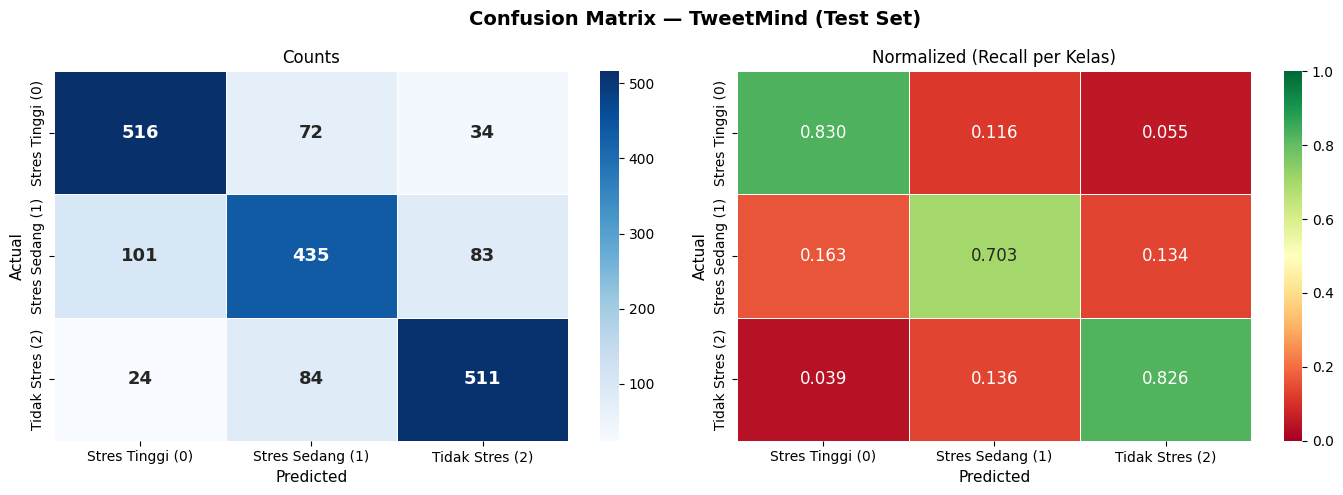

In [26]:
# ─── Confusion Matrix ──────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — TweetMind (Test Set)', fontsize=14, fontweight='bold')

short_names = ['Stres Tinggi (0)', 'Stres Sedang (1)', 'Tidak Stres (2)']

sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues', linewidths=0.5,
            xticklabels=short_names, yticklabels=short_names, annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Counts', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

sns.heatmap(cm_norm, annot=True, fmt='.3f', ax=axes[1], cmap='RdYlGn', linewidths=0.5,
            xticklabels=short_names, yticklabels=short_names, vmin=0, vmax=1,
            annot_kws={'size': 12})
axes[1].set_title('Normalized (Recall per Kelas)', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/artifacts/09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ─── Ringkasan Metrik Final ─────────────────────────────────────────────────
print("\n" + "=" * 65)
print("🏆  RINGKASAN PERFORMA MODEL TWEETMIND")
print("=" * 65)

metrics_summary = {
    'Metrik'            : ['Test Accuracy', 'Macro F1-Score', 'Weighted F1-Score',
                           'Best Val Accuracy', 'Epochs Dijalankan'],
    'Nilai'             : [f"{test_acc*100:.2f}%", f"{macro_f1:.4f}", f"{weighted_f1:.4f}",
                           f"{best_val_acc*100:.2f}%", f"{epochs_ran}"],
    'Target/Keterangan' : ['≥ 80%', '≥ 0.75', '≥ 0.75',
                           'Terbaik selama training', f'dari {EPOCHS} max']
}
df_metrics = pd.DataFrame(metrics_summary)
print(df_metrics.to_string(index=False))

target_met = test_acc >= 0.80
print(f"\n{'✅' if target_met else '⚠️'} Target akurasi 80%: {'TERCAPAI!' if target_met else 'Belum tercapai'}")


🏆  RINGKASAN PERFORMA MODEL TWEETMIND
           Metrik  Nilai       Target/Keterangan
    Test Accuracy 78.60%                   ≥ 80%
   Macro F1-Score 0.7852                  ≥ 0.75
Weighted F1-Score 0.7853                  ≥ 0.75
Best Val Accuracy 79.14% Terbaik selama training
Epochs Dijalankan     30             dari 30 max

⚠️ Target akurasi 80%: Belum tercapai


## 9. Simpan & Export Model

In [28]:
# ─── Export Model ke format .keras ─────────────────────────────────────────
MODEL_SAVE_PATH = f'{OUTPUT_DIR}/models/tweetmind_stress_classifier.keras'

model.load_weights(BEST_CKPT)
model.save(MODEL_SAVE_PATH)

print(f"✅ Model berhasil disimpan ke: {MODEL_SAVE_PATH}")
print(f"   Format: .keras (TensorFlow Production Format)")

# Verifikasi reload
model_loaded = keras.models.load_model(
    MODEL_SAVE_PATH,
    custom_objects={'FocalLoss': FocalLoss}
)

sample_orig   = model.predict(X_test_pad[:5], verbose=0)
sample_loaded = model_loaded.predict(X_test_pad[:5], verbose=0)
assert np.allclose(sample_orig, sample_loaded, atol=1e-5), "Prediksi berbeda!"
print("\n✅ Verifikasi: model loaded OK dan prediksi konsisten!")

# Simpan konfigurasi
config = {
    'vocab_size'    : actual_vocab,
    'max_len'       : MAX_LEN,
    'embed_dim'     : EMBED_DIM,
    'batch_size'    : BATCH_SIZE,
    'num_classes'   : NUM_CLASSES,
    'label_map'     : {'0': 'Stres Tinggi', '1': 'Stres Sedang', '2': 'Tidak Stres'},
    'best_val_acc'  : round(best_val_acc, 4),
    'test_accuracy' : round(test_acc, 4),
    'macro_f1'      : round(macro_f1, 4),
    'model_path'    : MODEL_SAVE_PATH,
    'tokenizer_path': f'{OUTPUT_DIR}/models/tokenizer.pkl',
    'training_date' : datetime.now().isoformat()
}

with open(f'{OUTPUT_DIR}/models/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"\n💾 Konfigurasi tersimpan!")

✅ Model berhasil disimpan ke: /content/drive/MyDrive/TweetMind_CC26PSU250/models/tweetmind_stress_classifier.keras
   Format: .keras (TensorFlow Production Format)

✅ Verifikasi: model loaded OK dan prediksi konsisten!

💾 Konfigurasi tersimpan!


## 10. Inference Script — Kode Prediksi Siap Produksi

Kelas `TweetMindPredictor` siap diintegrasikan dengan **FastAPI** endpoint `/predict`.


In [29]:
# ─── Kelas Inference Siap Produksi ─────────────────────────────────────────

class TweetMindPredictor:
    """Inference engine untuk model TweetMind Stress Classifier.

    Usage:
        predictor = TweetMindPredictor(model_path, tokenizer_path)
        result    = predictor.predict("I feel so overwhelmed with work stress")
    """

    LABEL_MAP  = {0: 'Stres Tinggi', 1: 'Stres Sedang', 2: 'Tidak Stres'}
    STRESS_MAP = {0: 'Tinggi', 1: 'Sedang', 2: 'Rendah'}

    def __init__(self, model_path: str, tokenizer_path: str, max_len: int = MAX_LEN):
        self.max_len = max_len

        with open(tokenizer_path, 'rb') as f:
            self.tokenizer = pickle.load(f)

        self.model = keras.models.load_model(
            model_path,
            custom_objects={'FocalLoss': FocalLoss}
        )
        print(f"✅ TweetMindPredictor siap! Model: {model_path.split('/')[-1]}")

    def _preprocess(self, text: str) -> np.ndarray:
        cleaned = clean_tweet(text, apply_stemming=False)
        seq     = self.tokenizer.texts_to_sequences([cleaned])
        padded  = pad_sequences(seq, maxlen=self.max_len, padding='post', truncating='post')
        return padded

    def predict(self, text: str) -> dict:
        """Prediksi stress level dari satu teks tweet.

        Returns:
            dict: label, label_text, stress, confidence, probabilities, input_clean
        """
        padded     = self._preprocess(text)
        proba      = self.model.predict(padded, verbose=0)[0]
        label      = int(np.argmax(proba))
        confidence = float(proba[label])

        return {
            'label'        : label,
            'label_text'   : self.LABEL_MAP[label],
            'stress'       : self.STRESS_MAP[label],
            'confidence'   : round(confidence, 4),
            'probabilities': {
                'Stres Tinggi (0)': round(float(proba[0]), 4),
                'Stres Sedang (1)': round(float(proba[1]), 4),
                'Tidak Stres (2)': round(float(proba[2]), 4),
            },
            'input_clean': clean_tweet(text)
        }

    def predict_batch(self, texts: list) -> list:
        """Prediksi batch beberapa teks sekaligus."""
        cleaned = [clean_tweet(t) for t in texts]
        seqs    = self.tokenizer.texts_to_sequences(cleaned)
        padded  = pad_sequences(seqs, maxlen=self.max_len, padding='post', truncating='post')
        probas  = self.model.predict(padded, verbose=0)
        labels  = np.argmax(probas, axis=1)

        return [{
            'text'      : t[:80] + '...' if len(t) > 80 else t,
            'label'     : int(lbl),
            'stress'    : self.STRESS_MAP[int(lbl)],
            'confidence': round(float(probas[i][int(lbl)]), 4)
        } for i, (t, lbl) in enumerate(zip(texts, labels))]

print("✅ Kelas TweetMindPredictor siap digunakan!")

✅ Kelas TweetMindPredictor siap digunakan!


In [30]:
# ─── Demo Inference ─────────────────────────────────────────────────────────
predictor = TweetMindPredictor(
    model_path    =MODEL_SAVE_PATH,
    tokenizer_path=f'{OUTPUT_DIR}/models/tokenizer.pkl'
)

test_tweets = [
    "I'm completely overwhelmed with work. The deadlines are killing me and I can't sleep. Feeling so stressed.",
    "Feeling a bit tired today after a long week. Mental health matters and I'm trying to take care of myself.",
    "What an amazing day! Just celebrated my birthday with friends. So happy and grateful for everything!",
    "PTSD MentalHealthMatters struggling with dark thoughts every night",
]

print("=" * 65)
print("🔮 DEMO INFERENCE — TweetMindPredictor")
print("=" * 65)

for i, tweet in enumerate(test_tweets, 1):
    result = predictor.predict(tweet)
    print(f"\n[Tweet {i}]")
    print(f"  Input      : {tweet[:80]}{'...' if len(tweet)>80 else ''}")
    print(f"  Cleaned    : {result['input_clean'][:70]}")
    print(f"  Prediksi   : Label {result['label']} — {result['stress']}")
    print(f"  Confidence : {result['confidence']*100:.1f}%")
    for k, v in result['probabilities'].items():
        bar = '█' * int(v * 25)
        print(f"  {k}: {bar:<25} {v*100:.1f}%")

✅ TweetMindPredictor siap! Model: tweetmind_stress_classifier.keras
🔮 DEMO INFERENCE — TweetMindPredictor

[Tweet 1]
  Input      : I'm completely overwhelmed with work. The deadlines are killing me and I can't s...
  Cleaned    : completely overwhelmed work deadlines killing sleep feeling stressed
  Prediksi   : Label 2 — Rendah
  Confidence : 88.7%
  Stres Tinggi (0):                           0.0%
  Stres Sedang (1): ██                        11.3%
  Tidak Stres (2): ██████████████████████    88.7%

[Tweet 2]
  Input      : Feeling a bit tired today after a long week. Mental health matters and I'm tryin...
  Cleaned    : feeling bit tired long mental health matters trying take care
  Prediksi   : Label 1 — Sedang
  Confidence : 60.5%
  Stres Tinggi (0):                           0.0%
  Stres Sedang (1): ███████████████           60.5%
  Tidak Stres (2): █████████                 39.5%

[Tweet 3]
  Input      : What an amazing day! Just celebrated my birthday with friends. So happy a

In [31]:
# ─── Batch Inference Demo ──────────────────────────────────────────────────
batch_results = predictor.predict_batch(test_tweets)
print("\n📊 BATCH INFERENCE SUMMARY:")
df_results = pd.DataFrame(batch_results)
print(df_results.to_string(index=False))


📊 BATCH INFERENCE SUMMARY:
                                                                               text  label stress  confidence
I'm completely overwhelmed with work. The deadlines are killing me and I can't s...      2 Rendah      0.8869
Feeling a bit tired today after a long week. Mental health matters and I'm tryin...      1 Sedang      0.6052
What an amazing day! Just celebrated my birthday with friends. So happy and grat...      0 Tinggi      0.9990
                 PTSD MentalHealthMatters struggling with dark thoughts every night      1 Sedang      0.9585


In [32]:
# ─── Simpan predict.py — Script Inference Siap Produksi ────────────────────
predict_script = '''"""predict.py — TweetMind Inference Script (Optimized)

Digunakan oleh FastAPI endpoint /predict.

Usage:
    from predict import TweetMindPredictor
    predictor = TweetMindPredictor(\'path/to/model.keras\', \'path/to/tokenizer.pkl\')
    result = predictor.predict(\"I feel so stressed\")
"""

import re
import pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.losses import Loss
from tensorflow.keras.preprocessing.sequence import pad_sequences

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download(\"stopwords\", quiet=True)
nltk.download(\"punkt\", quiet=True)

STOPWORDS_EN     = set(stopwords.words(\"english\"))
CUSTOM_STOPWORDS = {\"rt\", \"via\", \"amp\", \"would\", \"could\", \"also\", \"get\", \"got\"}
STOPWORDS_FINAL  = STOPWORDS_EN.union(CUSTOM_STOPWORDS)


class FocalLoss(Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true  = tf.cast(y_true, tf.int32)
        y_true  = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce_loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t     = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_w = self.alpha * tf.pow(1.0 - p_t, self.gamma)
        return tf.reduce_mean(focal_w * ce_loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({\"gamma\": self.gamma, \"alpha\": self.alpha})
        return cfg


def clean_tweet(text: str) -> str:
    if not isinstance(text, str):
        return \"\"
    text = text.lower()
    text = re.sub(r\"https?://\\S+|www\\.\\S+\", \"\", text)
    text = re.sub(r\"@\\w+\", \"\", text)
    text = re.sub(r\"#(\\w+)\", r\"\\1\", text)
    text = re.sub(r\"[^\\x00-\\x7F]+\", \" \", text)
    text = re.sub(r\"[^a-z\\s]\", \" \", text)
    text = re.sub(r\"\\s+\", \" \", text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS_FINAL and len(t) > 2]
    return \" \".join(tokens)


class TweetMindPredictor:
    LABEL_MAP  = {0: \"Stres Tinggi\", 1: \"Stres Sedang\", 2: \"Tidak Stres\"}
    STRESS_MAP = {0: \"Tinggi\", 1: \"Sedang\", 2: \"Rendah\"}

    def __init__(self, model_path: str, tokenizer_path: str, max_len: int = 50):
        self.max_len = max_len
        with open(tokenizer_path, \"rb\") as f:
            self.tokenizer = pickle.load(f)
        self.model = keras.models.load_model(
            model_path, custom_objects={\"FocalLoss\": FocalLoss}
        )

    def predict(self, text: str) -> dict:
        cleaned = clean_tweet(text)
        seq     = self.tokenizer.texts_to_sequences([cleaned])
        padded  = pad_sequences(seq, maxlen=self.max_len, padding=\"post\", truncating=\"post\")
        proba   = self.model.predict(padded, verbose=0)[0]
        label   = int(np.argmax(proba))
        return {
            \"label\"        : label,
            \"label_text\"   : self.LABEL_MAP[label],
            \"stress\"       : self.STRESS_MAP[label],
            \"confidence\"   : round(float(proba[label]), 4),
            \"probabilities\": {
                \"Stres Tinggi\": round(float(proba[0]), 4),
                \"Stres Sedang\": round(float(proba[1]), 4),
                \"Tidak Stres\": round(float(proba[2]), 4),
            }
        }
'''

with open(f'{OUTPUT_DIR}/models/predict.py', 'w') as f:
    f.write(predict_script)

print(f"✅ predict.py disimpan di: {OUTPUT_DIR}/models/predict.py")
print("   Siap diintegrasikan dengan FastAPI!")

✅ predict.py disimpan di: /content/drive/MyDrive/TweetMind_CC26PSU250/models/predict.py
   Siap diintegrasikan dengan FastAPI!
